In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def det_2x2(M):
    """T1: Cálculo manual do determinante para matrizes 2x2 (ad - bc)"""
    if M.shape != (2, 2):
        raise ValueError("A matriz deve ser de dimensão 2x2.")
    return M[0,0]*M[1,1] - M[0,1]*M[1,0]

def gauss_det(A):
    """T2: Cálculo do determinante usando Eliminação de Gauss (Matriz Triangular)"""
    n = len(A)
    M = A.copy().astype(float)
    det = 1.0
    
    for i in range(n):
        # Pivotagem simples: se o elemento da diagonal for zero, troca com uma linha abaixo
        if M[i,i] == 0:
            for j in range(i+1, n):
                if M[j,i] != 0:
                    M[[i,j]] = M[[j,i]] # Troca as linhas i e j
                    det *= -1           # Trocar linhas inverte o sinal do determinante
                    break
            else:
                return 0.0 # Se toda a coluna for zero, o determinante é zero
                
        det *= M[i,i]
        
        # Eliminação Gaussiana para fazer zeros abaixo da diagonal
        for j in range(i+1, n):
            factor = M[j,i] / M[i,i]
            M[j,i:] -= factor * M[i,i:]
            
    return det

In [3]:
def inversa_gauss_jordan(A):
    """T5: Cálculo da matriz inversa usando o método de Gauss-Jordan [A|I]"""
    n = len(A)
    # Criar a matriz identidade com as mesmas dimensões
    I = np.eye(n)
    # Juntar as duas matrizes lado a lado
    aug = np.hstack([A, I]).astype(float)
    
    for i in range(n):
        # Tornar o pivô igual a 1
        pivot = aug[i,i]
        if pivot == 0:
            raise ValueError("A matriz é singular e não pode ser invertida.")
        aug[i] /= pivot
        
        # Fazer zeros em todas as outras posições da coluna do pivô
        for j in range(n):
            if i != j:
                factor = aug[j,i]
                aug[j] -= factor * aug[i]
                
    # Retornar apenas a parte da direita, que agora é a inversa
    return aug[:, n:]

In [4]:
def visualizar_transformacao(A, output_path="determinante_area.png"):
    """T6: Visualização geométrica do efeito do determinante na área"""
    # Definição dos vértices de um quadrado unitário (0,0) -> (1,0) -> (1,1) -> (0,1) -> volta ao início
    quadrado = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
    
    # Aplicar a transformação multiplicando os pontos pela transposta da matriz
    paralelogramo = quadrado @ A.T
    
    # Calcular o determinante real para o título
    det_val = np.linalg.det(A)
    
    # Criar o gráfico
    plt.figure(figsize=(7, 7))
    
    # Desenhar o quadrado original (linha tracejada azul)
    plt.plot(quadrado[:,0], quadrado[:,1], 'b--', linewidth=2, label='Original (Área = 1)')
    
    # Desenhar o paralelogramo transformado (preenchido a vermelho claro)
    plt.fill(paralelogramo[:,0], paralelogramo[:,1], 'r', alpha=0.3, label=f'Transformada (Área = {abs(det_val):.2f})')
    plt.plot(paralelogramo[:,0], paralelogramo[:,1], 'r-', linewidth=2)
    
    # Configurações de design do gráfico
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhline(0, color='black',linewidth=1)
    plt.axvline(0, color='black',linewidth=1)
    plt.legend(loc='upper left')
    plt.title(f"Transformação Linear: Fator de Escala |det(A)| = {abs(det_val):.2f}")
    
    # Ajustar limites do eixo com uma margem de segurança
    all_x = np.concatenate([quadrado[:,0], paralelogramo[:,0]])
    all_y = np.concatenate([quadrado[:,1], paralelogramo[:,1]])
    plt.xlim(min(all_x) - 1, max(all_x) + 1)
    plt.ylim(min(all_y) - 1, max(all_y) + 1)
    
    # Guardar a imagem na pasta como pedido
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[Sucesso] Gráfico gerado e guardado em: {output_path}")

=== ASSIGNMENT 03: RESULTADOS COMPUTACOINAIS ===

T1: Determinante Manual (2x2): 5
T2: Determinante via Gauss: 5.00

T3: det(A @ I) == det(A)? True

T4: Número de Condição da Matriz: 2.6180

T5: Matriz Inversa calculada:
[[ 0.6 -0.2]
 [-0.2  0.4]]
Verificação (A @ A_inv == I): True

T6: A gerar a visualização geométrica...


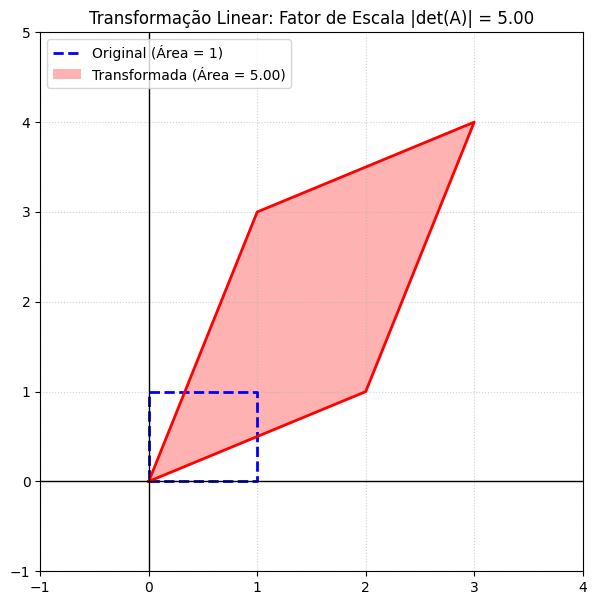

[Sucesso] Gráfico gerado e guardado em: determinante_area.png


In [5]:
# Definir a matriz A de teste (podes mudar os valores para os do teu enunciado se quiseres)
A_teste = np.array([[2, 1], [1, 3]])

print("=== ASSIGNMENT 03: RESULTADOS COMPUTACOINAIS ===")

# 1. Testar determinantes
det_m = det_2x2(A_teste)
det_g = gauss_det(A_teste)
print(f"\nT1: Determinante Manual (2x2): {det_m}")
print(f"T2: Determinante via Gauss: {det_g:.2f}")

# T3: Verificação de propriedades usando matrizes identidade
I = np.eye(2)
print(f"\nT3: det(A @ I) == det(A)? {np.allclose(gauss_det(A_teste @ I), det_g)}")

# T4: Calcular o Número de Condição (Condition Number)
cond_num = np.linalg.cond(A_teste)
print(f"\nT4: Número de Condição da Matriz: {cond_num:.4f}")

# 5. Testar a matriz inversa funcional
A_inv = inversa_gauss_jordan(A_teste)
print(f"\nT5: Matriz Inversa calculada:\n{A_inv}")
print(f"Verificação (A @ A_inv == I): {np.allclose(A_teste @ A_inv, np.eye(2))}")

# 6. Correr a visualização e gerar o ficheiro PNG na pasta do trabalho
print("\nT6: A gerar a visualização geométrica...")
visualizar_transformacao(A_teste, output_path="determinante_area.png")